In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
cluster_data = pd.read_csv('../results/autoencoder/csv/cluster_stats_left.csv')
cluster_pain_data = pd.read_csv('../results/autoencoder_pain/csv/cluster_stats_left.csv')
kl_data = pd.read_csv('../csv/kl_clusters_left.csv')

/Users/filippofocaccia/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [14]:
plt.rcdefaults()


Computed cluster mapping (pain → AE):
{4: 4, 1: 2, 0: 0, 2: 1, 3: 3}


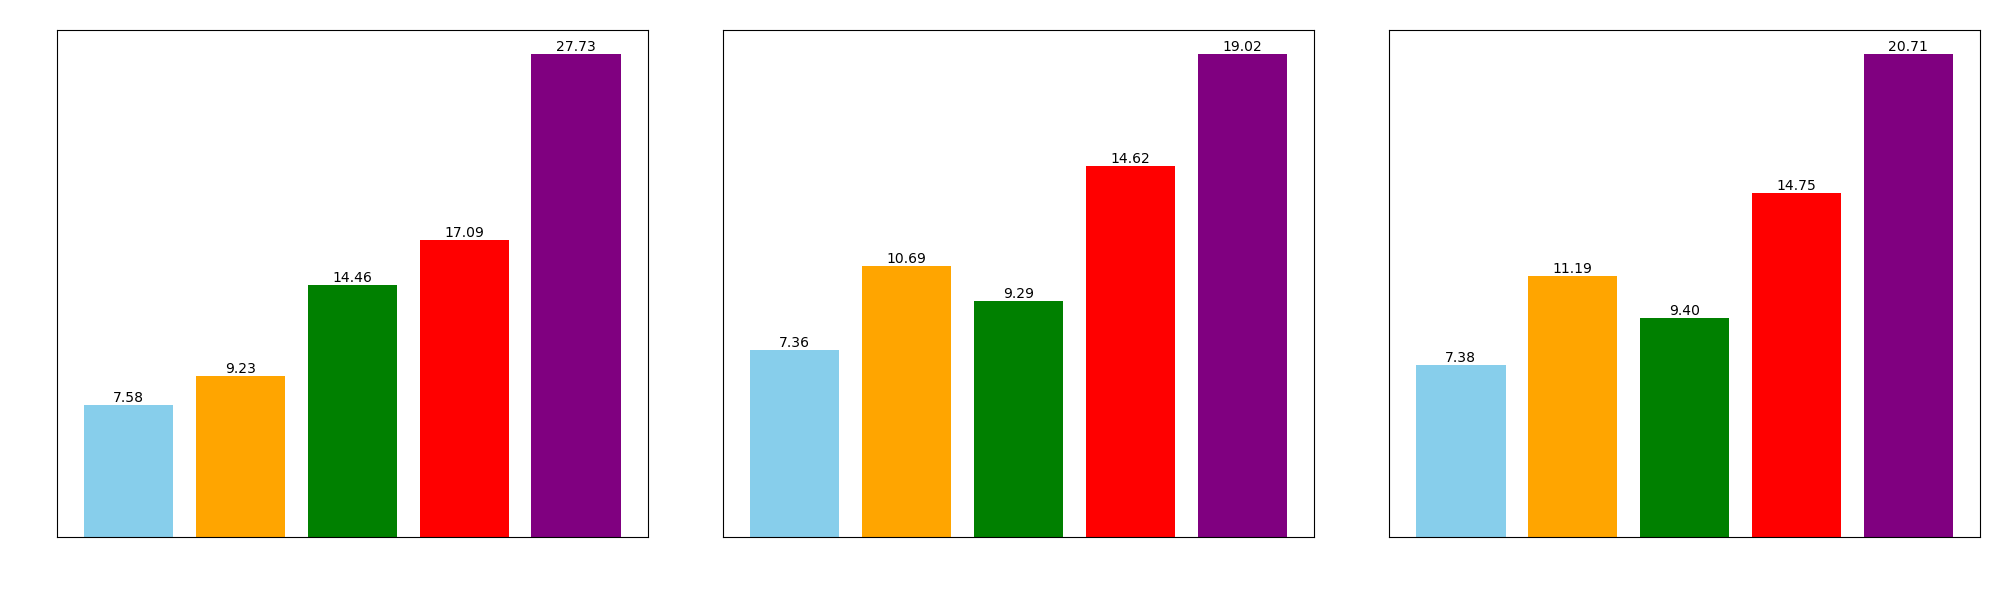

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ----------------------------------------------------------
# 1. CLEAN DATAFRAMES
# ----------------------------------------------------------
cluster_data.columns = cluster_data.columns.str.strip()
cluster_pain_data.columns = cluster_pain_data.columns.str.strip()
kl_data.columns = kl_data.columns.str.strip()

# ----------------------------------------------------------
# 2. DEFINE FORCED CLUSTER ORDER
# ----------------------------------------------------------
cluster_order = [4, 1, 2, 0, 3]

colors = ['skyblue', 'orange', 'green', 'red', 'purple']  # ordered colors


# ----------------------------------------------------------
# 3. REORDER AE CLUSTERS
# ----------------------------------------------------------
cluster_data = (
    cluster_data
    .set_index("cluster")
    .loc[cluster_order]
    .reset_index()
)

# x-positions for plotting
x = np.arange(len(cluster_order))


# ----------------------------------------------------------
# 4. COMPUTE CLUSTER SIMILARITY (AE vs Pain)
# ----------------------------------------------------------
left_vals  = cluster_data['V00WOMTSL_MEAN'].values
right_vals = cluster_pain_data.set_index("cluster").loc[cluster_order]['V00WOMTSL_MEAN'].values

# Compute 5×5 distance matrix
diff_matrix = np.abs(left_vals[:, None] - right_vals[None, :])

# Greedy optimal matching
mapping = {}
remaining_left  = list(range(5))
remaining_right = list(range(5))

for _ in range(5):
    sub = diff_matrix[np.ix_(remaining_left, remaining_right)]
    i, j = divmod(sub.argmin(), sub.shape[1])
    left_cluster  = cluster_data['cluster'].iloc[remaining_left[i]]
    right_cluster = cluster_order[remaining_right[j]]

    mapping[right_cluster] = left_cluster

    del remaining_left[i]
    del remaining_right[j]

print("Computed cluster mapping (pain → AE):")
print(mapping)


# ----------------------------------------------------------
# 5. APPLY MAPPING TO PAIN-ENCODED CLUSTERS
# ----------------------------------------------------------
cluster_pain_data['mapped_cluster'] = cluster_pain_data['cluster'].map(mapping)

# Reorder using the mapped cluster ID
cluster_pain_data = (
    cluster_pain_data
    .set_index('mapped_cluster')
    .loc[cluster_order]
    .reset_index()
)


# ----------------------------------------------------------
# 6. PLOTTING — All 3 panels aligned
# ----------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.patch.set_alpha(0)      # transparent figure background


plt.rcParams['axes.labelcolor'] = 'white'
plt.rcParams['xtick.color'] = 'white'
plt.rcParams['ytick.color'] = 'white'
plt.rcParams['axes.titlecolor'] = 'white'
# --------------------- PANEL 1 -----------------------------
bars = axes[0].bar(
    kl_data['KL_GRADE'],
    kl_data['V00WOMTSL'],
    color=colors,
)
for bar in bars:
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, h, f"{h:.2f}",
                 ha="center", va="bottom")

axes[0].set_title("WOMAC average score per KL grade")
axes[0].set_xlabel("KL Grade")
axes[0].set_ylabel("WOMAC score")


# --------------------- PANEL 2 -----------------------------
bars = axes[1].bar(
    x,
    cluster_data['V00WOMTSL_MEAN'],
    color=colors
)
for bar in bars:
    h = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, h, f"{h:.2f}",
                 ha="center", va="bottom")

axes[1].set_title("WOMAC average score per cluster (AE)")
axes[1].set_xlabel("Cluster")
axes[1].set_ylabel("WOMAC score")
axes[1].set_xticks(x)
axes[1].set_xticklabels(cluster_order)


# --------------------- PANEL 3 -----------------------------
bars = axes[2].bar(
    x,
    cluster_pain_data['V00WOMTSL_MEAN'],
    color=colors
)
for bar in bars:
    h = bar.get_height()
    axes[2].text(bar.get_x() + bar.get_width()/2, h, f"{h:.2f}",
                 ha="center", va="bottom")

axes[2].set_title("WOMAC average score per cluster (Pain-Encoded)")
axes[2].set_xlabel("Cluster")
axes[2].set_ylabel("WOMAC score")
axes[2].set_xticks(x)
axes[2].set_xticklabels(cluster_order)

plt.tight_layout()
plt.show()



JSN-based cluster mapping (pain → AE):
{4: 4, 1: 2, 2: 1, 0: 0, 3: 3}


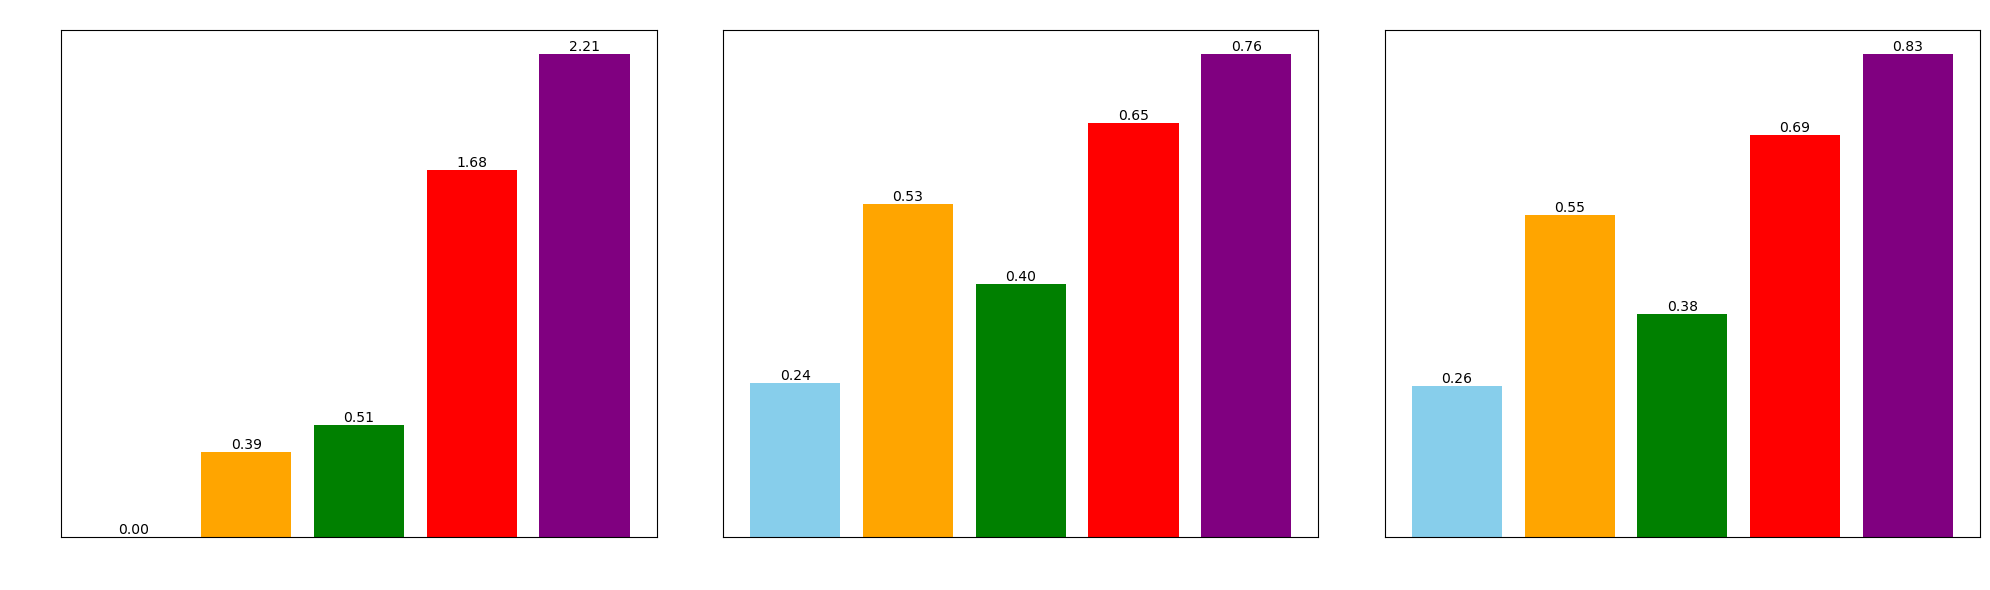

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------------------------------------
# 1. CLEAN THE DATA (remove accidental spaces)
# ----------------------------------------------------------
cluster_data.columns = cluster_data.columns.str.strip()
cluster_pain_data.columns = cluster_pain_data.columns.str.strip()
kl_data.columns = kl_data.columns.str.strip()

# ----------------------------------------------------------
# 2. FIXED CLUSTER ORDER FOR DISPLAY
# ----------------------------------------------------------
cluster_order = [4, 1, 2, 0, 3]
colors = ['skyblue', 'orange', 'green', 'red', 'purple']

# ----------------------------------------------------------
# 3. REORDER AE CLUSTERS (LEFT PLOT)
# ----------------------------------------------------------
cluster_data_sorted = (
    cluster_data
    .set_index("cluster")
    .loc[cluster_order]
    .reset_index()
)

x = np.arange(len(cluster_order))

# ----------------------------------------------------------
# 4. COMPUTE MATCHING BETWEEN AE CLUSTERS AND PAIN CLUSTERS
#     (based on JSN: V00XRJSM_L_MEAN)
# ----------------------------------------------------------

left_jsn  = cluster_data_sorted['V00XRJSM_L_MEAN'].values
right_jsn = cluster_pain_data.set_index("cluster").loc[cluster_order]['V00XRJSM_L_MEAN'].values

diff_matrix = np.abs(left_jsn[:, None] - right_jsn[None, :])

mapping = {}
remaining_left  = list(range(5))
remaining_right = list(range(5))

for _ in range(5):
    sub = diff_matrix[np.ix_(remaining_left, remaining_right)]
    i, j = divmod(sub.argmin(), sub.shape[1])

    left_cluster  = cluster_order[remaining_left[i]]
    right_cluster = cluster_order[remaining_right[j]]

    mapping[right_cluster] = left_cluster

    del remaining_left[i]
    del remaining_right[j]

print("\nJSN-based cluster mapping (pain → AE):")
print(mapping)

# ----------------------------------------------------------
# 5. APPLY MAPPING TO PAIN CLUSTERS
# ----------------------------------------------------------
cluster_pain_data['mapped_cluster'] = cluster_pain_data['cluster'].map(mapping)

cluster_pain_sorted = (
    cluster_pain_data
    .set_index("mapped_cluster")
    .loc[cluster_order]
    .reset_index()
)

# ----------------------------------------------------------
# 6. PLOTTING
# ----------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.patch.set_alpha(0)      # transparent figure background


plt.rcParams['axes.labelcolor'] = 'white'
plt.rcParams['xtick.color'] = 'white'
plt.rcParams['ytick.color'] = 'white'
plt.rcParams['axes.titlecolor'] = 'white'
# --------------------- PANEL 1: KL Grades ---------------------
bars = axes[0].bar(
    kl_data['KL_GRADE'],
    kl_data['V00XRJSM_L'],
    color=colors
)
for bar in bars:
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, h, f"{h:.2f}",
                 ha='center', va='bottom')

axes[0].set_title("JSN per KL grade")
axes[0].set_xlabel("KL Grade")
axes[0].set_ylabel("OARSI JSN grade (0–3)")

# --------------------- PANEL 2: AE Clusters --------------------
bars = axes[1].bar(
    x,
    cluster_data_sorted['V00XRJSM_L_MEAN'],
    color=colors
)
for bar in bars:
    h = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, h, f"{h:.2f}",
                 ha='center', va='bottom')

axes[1].set_title("JSN per AE cluster")
axes[1].set_xlabel("Cluster")
axes[1].set_ylabel("OARSI JSN grade (0–3)")
axes[1].set_xticks(x)
axes[1].set_xticklabels(cluster_order)

# --------------------- PANEL 3: Pain Clusters (Mapped) --------
bars = axes[2].bar(
    x,
    cluster_pain_sorted['V00XRJSM_L_MEAN'],
    color=colors
)
for bar in bars:
    h = bar.get_height()
    axes[2].text(bar.get_x() + bar.get_width()/2, h, f"{h:.2f}",
                 ha='center', va='bottom')

axes[2].set_title("JSN per cluster (pain-encoded)")
axes[2].set_xlabel("Cluster")
axes[2].set_ylabel("OARSI JSN grade (0–3)")
axes[2].set_xticks(x)
axes[2].set_xticklabels(cluster_order)

plt.tight_layout()
plt.show()


In [2]:
cluster_data.head()

,cluster,N_PATIENTS,SURGERY_PCT_YES,SURGERY_PCT_NO,KL_LEFT_0_PCT,KL_LEFT_1_PCT,KL_LEFT_2_PCT,KL_LEFT_3_PCT,KL_LEFT_4_PCT,V00WOMTSL_MEAN,V00KOOSKPL_MEAN,V00KOOSYML_MEAN,V00KOOSQOL_MEAN,V00XRJSL_L_MEAN,V00XRJSM_L_MEAN
0,0,942,13.588110,86.411890,0.296178,0.175159,0.298301,0.177282,0.053079,14.618577,81.937473,84.267516,63.217834,0.146497,0.654989
1,1,1213,8.656224,91.343776,0.380049,0.186315,0.249794,0.149217,0.034625,10.693735,86.222836,88.088458,67.707420,0.119538,0.526793
2,2,1137,8.003518,91.996482,0.481091,0.179420,0.220756,0.102023,0.016711,9.286280,88.119085,89.357608,71.114160,0.093228,0.401055
3,3,458,14.847162,85.152838,0.161572,0.161572,0.395197,0.237991,0.043668,19.016812,78.246507,80.290611,58.193231,0.200873,0.764192
4,4,676,4.733728,95.266272,0.585799,0.183432,0.155325,0.060651,0.014793,7.355030,90.248521,91.112130,74.565680,0.073964,0.244083


In [5]:
cluster_pain_data.head()

,cluster,N_PATIENTS,SURGERY_PCT_YES,SURGERY_PCT_NO,KL_LEFT_0_PCT,KL_LEFT_1_PCT,KL_LEFT_2_PCT,KL_LEFT_3_PCT,KL_LEFT_4_PCT,V00WOMTSL_MEAN,V00KOOSKPL_MEAN,V00KOOSYML_MEAN,V00KOOSQOL_MEAN,V00XRJSL_L_MEAN,V00XRJSM_L_MEAN
0,0,875,13.714286,86.285714,0.265143,0.163429,0.307429,0.205714,0.058286,14.753371,81.696800,83.869943,63.035543,0.172571,0.690286
1,1,1212,7.260726,92.739274,0.477723,0.183168,0.226898,0.096535,0.015677,9.400330,87.902228,89.423350,71.000165,0.099835,0.382838
2,2,1151,9.470026,90.529974,0.369244,0.186794,0.260643,0.147698,0.035621,11.187228,85.760730,87.579322,66.977063,0.114683,0.552563
3,3,378,16.931217,83.068783,0.142857,0.161376,0.394180,0.251323,0.050265,20.710317,76.583333,78.788360,56.085450,0.193122,0.828042
4,4,810,5.308642,94.691358,0.576543,0.187654,0.158025,0.064198,0.013580,7.376543,90.281975,91.163827,74.193580,0.066667,0.259259


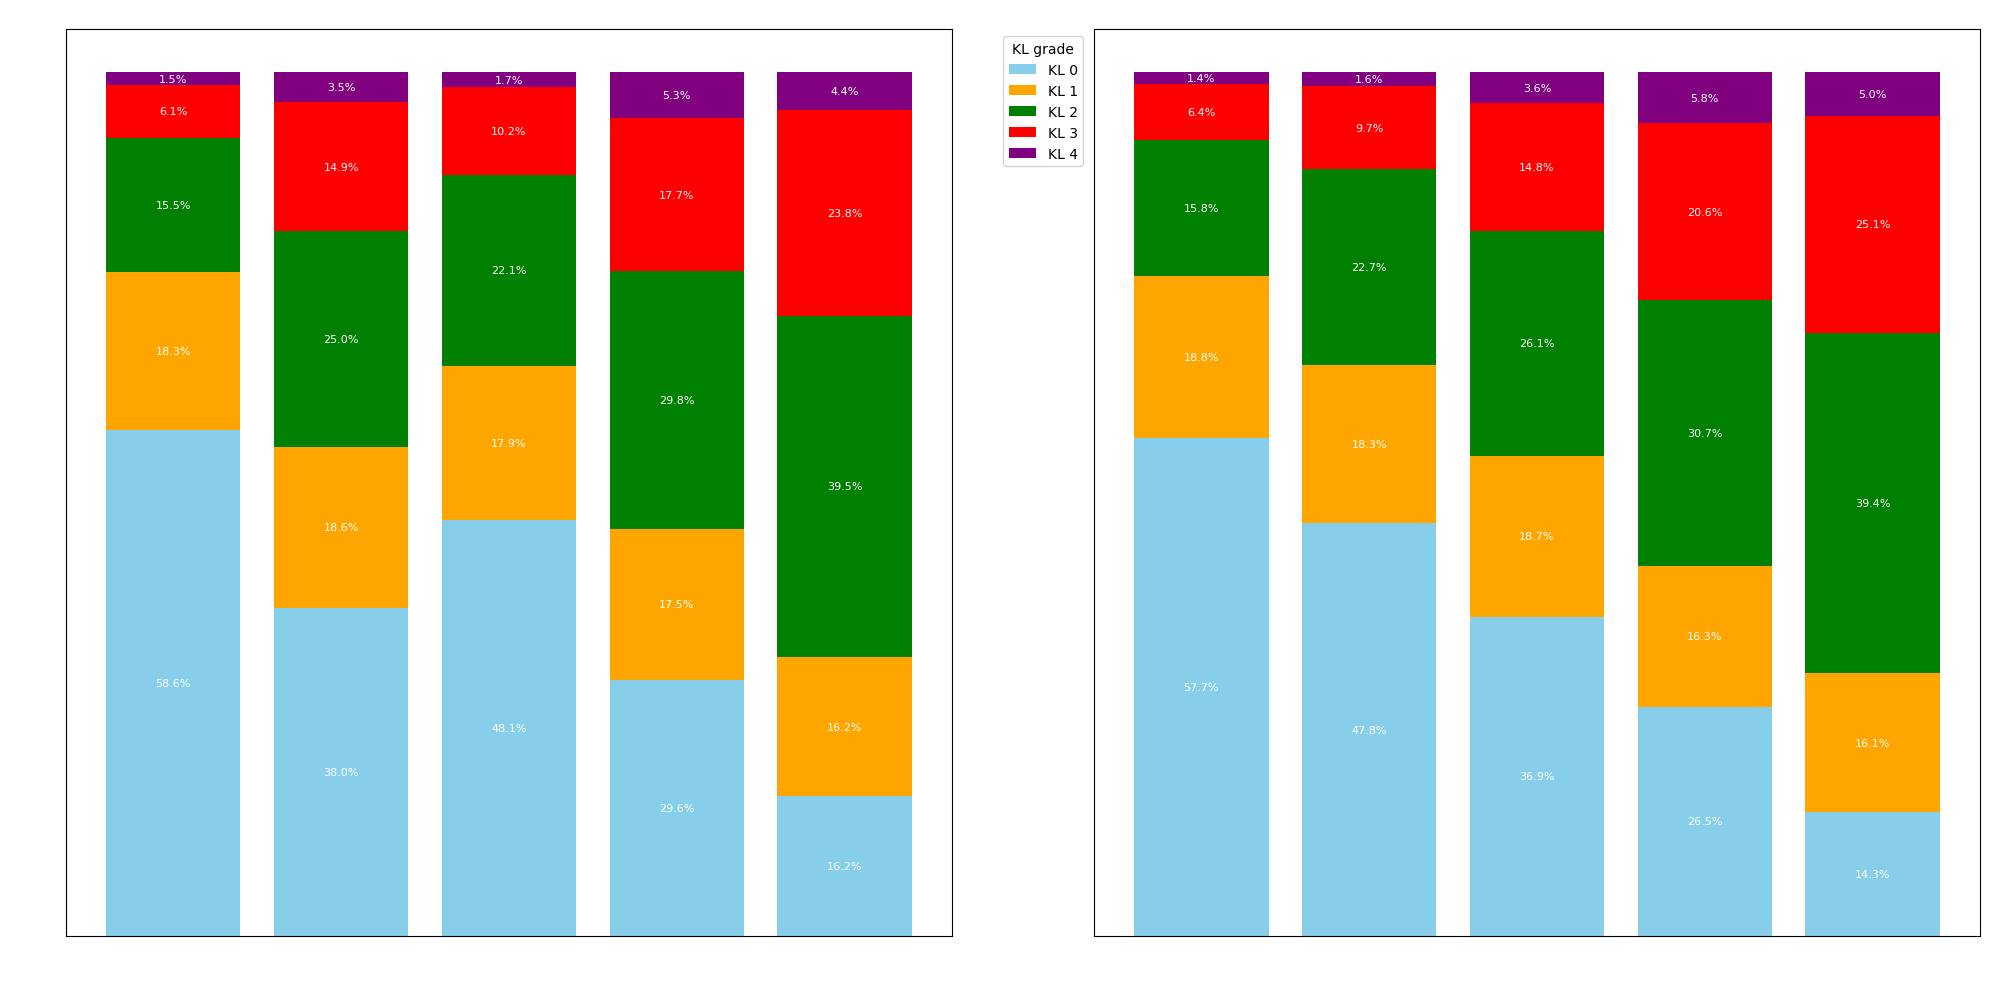

In [5]:
# Stacked bar chart of KL grade distribution per cluster
cluster_data.columns = cluster_data.columns.str.strip()
cluster_pain_data.columns = cluster_pain_data.columns.str.strip()
kl_cols = ["KL_LEFT_0_PCT", "KL_LEFT_1_PCT", "KL_LEFT_2_PCT", "KL_LEFT_3_PCT", "KL_LEFT_4_PCT"]
labels = ["KL 0", "KL 1", "KL 2", "KL 3", "KL 4"]
cluster_order = [4, 1, 2, 0, 3]  # keep same order as earlier
colors_kl = ['skyblue', 'orange', 'green', 'red', 'purple']


fig, axes = plt.subplots(1, 2, figsize=(20, 10), sharey=True)
fig.patch.set_alpha(0)      # transparent figure background


plt.rcParams['axes.labelcolor'] = 'white'
plt.rcParams['xtick.color'] = 'white'
plt.rcParams['ytick.color'] = 'white'
plt.rcParams['axes.titlecolor'] = 'white'

# ---------- AE clusters ----------
cd_sorted = cluster_data.set_index("cluster").loc[cluster_order].reset_index()
x = np.arange(len(cluster_order))
bottom = np.zeros(len(cluster_order))

for col, label, c in zip(kl_cols, labels, colors_kl):
    vals = cd_sorted[col].values * 100  # convert to %
    bars = axes[0].bar(x, vals, bottom=bottom, label=label, color=c)
    # add text on each segment
    for bar, v, b in zip(bars, vals, bottom):
        if v > 0:
            axes[0].text(
                bar.get_x() + bar.get_width() / 2,
                b + v / 2,
                f"{v:.1f}%",
                ha="center",
                va="center",
                fontsize=8,
                color="white"
            )
    bottom += vals

axes[0].set_title("KL distribution per AE cluster")
axes[0].set_xlabel("Cluster")
axes[0].set_xticks(x)
axes[0].set_xticklabels(cluster_order)
axes[0].set_ylabel("Percentage of patients")
axes[0].legend(title="KL grade", bbox_to_anchor=(1.05, 1), loc="upper left")

# ---------- Pain-encoded clusters ----------
cp_sorted = cluster_pain_data.set_index("cluster").loc[cluster_order].reset_index()
x2 = np.arange(len(cluster_order))
bottom = np.zeros(len(cluster_order))

for col, label, c in zip(kl_cols, labels, colors_kl):
    vals = cp_sorted[col].values * 100
    bars = axes[1].bar(x2, vals, bottom=bottom, label=label, color=c)
    for bar, v, b in zip(bars, vals, bottom):
        if v > 0:
            axes[1].text(
                bar.get_x() + bar.get_width() / 2,
                b + v / 2,
                f"{v:.1f}%",
                ha="center",
                va="center",
                fontsize=8,
                color="white"
            )
    bottom += vals

axes[1].set_title("KL distribution per pain-encoded AE cluster")
axes[1].set_xlabel("Cluster")
axes[1].set_xticks(x2)
axes[1].set_xticklabels(cluster_order)

plt.tight_layout()
plt.show()